In [21]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

USGS_PATH = "../data/usgs_data/usgs_m4_2005_2025.csv"
ALLSTATIONS_GLOB = "../data/csv_data_allstations/*_60min.csv"

# 22 stacje z >=95% kompletnosci danych w oknie testu (t0 .. t0+1675 dni) -
# wybrane 2026-07-17 po sprawdzeniu jakosci calego zbioru allstations
# (2011-2019). Sortowane wg kompletnosci malejaco.
GOOD_STATIONS = [
    "OULU", "THUL", "LMKS", "APTY", "SOPB", "JUNG1", "SOPO", "FSMT", "MOSC",
    "JUNG", "NEWK", "PWNK", "MXCO", "NAIN", "HRMS", "TERA", "INVK", "ATHN",
    "AATB", "PSNM", "NANM", "MCRL",
]

def load_earthquakes(min_mag=4.0):
    df = pd.read_csv(USGS_PATH, usecols=["time", "mag"])
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_localize(None)
    df = df[df["mag"] >= min_mag]
    return df.set_index("time")["mag"].sort_index()

def load_allstations():
    files = sorted(glob.glob(ALLSTATIONS_GLOB))
    dfs = []
    for f in files:
        df = pd.read_csv(f, sep=";", na_values=["null"])
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        dfs.append(df)
    full = pd.concat(dfs, ignore_index=True, sort=False)
    full = full.drop_duplicates(subset="timestamp").sort_values("timestamp")
    return full.set_index("timestamp")

def station_series_6h(full, station):
    """Pojedyncza stacja: numeryczne, >0, zresamplowane do 6h (jak Moskwa/Oulu/Auger)."""
    col = pd.to_numeric(full[station], errors="coerce")
    col = col[col > 0].dropna()
    return col.resample("6h").mean()

eq = load_earthquakes(min_mag=4.0)
allstations_raw = load_allstations()
print(f"EQ (M>=4.0): {len(eq)} zdarzen, {eq.index.min()} .. {eq.index.max()}")
print(f"Allstations raw: {len(allstations_raw)} wierszy, {allstations_raw.index.min()} .. {allstations_raw.index.max()}, "
      f"{allstations_raw.shape[1]} kolumn (stacji)")

cr_by_station = {s: station_series_6h(allstations_raw, s) for s in GOOD_STATIONS}
for s in GOOD_STATIONS:
    cr = cr_by_station[s]
    print(f"  {s}: {len(cr)} pomiarow (6h), {cr.index.min()} .. {cr.index.max()}")


EQ (M>=4.0): 290945 zdarzen, 2005-01-01 00:47:34.620000 .. 2025-01-31 23:57:39.481000
Allstations raw: 40008 wierszy, 2011-01-01 00:00:00 .. 2019-12-31 23:00:00, 53 kolumn (stacji)
  OULU: 13148 pomiarow (6h), 2011-01-01 00:00:00 .. 2019-12-31 18:00:00
  THUL: 13148 pomiarow (6h), 2011-01-01 00:00:00 .. 2019-12-31 18:00:00
  LMKS: 13148 pomiarow (6h), 2011-01-01 00:00:00 .. 2019-12-31 18:00:00
  APTY: 13148 pomiarow (6h), 2011-01-01 00:00:00 .. 2019-12-31 18:00:00
  SOPB: 13148 pomiarow (6h), 2011-01-01 00:00:00 .. 2019-12-31 18:00:00
  JUNG1: 13148 pomiarow (6h), 2011-01-01 00:00:00 .. 2019-12-31 18:00:00
  SOPO: 13148 pomiarow (6h), 2011-01-01 00:00:00 .. 2019-12-31 18:00:00
  FSMT: 13148 pomiarow (6h), 2011-01-01 00:00:00 .. 2019-12-31 18:00:00
  MOSC: 13128 pomiarow (6h), 2011-01-01 00:00:00 .. 2019-12-26 18:00:00
  JUNG: 13148 pomiarow (6h), 2011-01-01 00:00:00 .. 2019-12-31 18:00:00
  NEWK: 13148 pomiarow (6h), 2011-01-01 00:00:00 .. 2019-12-31 18:00:00
  PWNK: 13148 pomiarow (6h

In [22]:
def cosmoseismic_stat(cr, eq, t0, P_days, d_days, m, dt_days):
    N = int(P_days // d_days)
    edges = pd.date_range(t0, periods=N + 1, freq=pd.Timedelta(days=d_days))
    eq_edges = edges + pd.Timedelta(days=dt_days)

    cr_cats = pd.cut(cr.index, edges, right=False)
    cr_binned = cr.groupby(cr_cats, observed=False).mean().reindex(cr_cats.categories)
    cr_vals = cr_binned.to_numpy()

    eq_in_range = eq[(eq.index >= eq_edges[0]) & (eq.index < eq_edges[-1])]
    eq_cats = pd.cut(eq_in_range.index, eq_edges, right=False)
    eq_binned = eq_in_range.groupby(eq_cats, observed=False).sum().reindex(eq_cats.categories, fill_value=0.0)
    sm_vals = eq_binned.to_numpy()

    nCR_i, nCR_im1 = cr_vals[1:], cr_vals[:-1]
    dCR = nCR_i - nCR_im1
    Sm = sm_vals[1:]

    med_Sm = np.nanmedian(Sm)
    med_dCR = np.nanmedian(np.abs(dCR))

    A = Sm / med_Sm - 1
    B = np.abs(dCR) / med_dCR - 1

    valid = (
        (A != 0) & (B != 0) &
        (nCR_i > 0) & (nCR_im1 > 0) &
        (Sm > 0) &
        ~np.isnan(A) & ~np.isnan(B)
    )

    c_valid = (A * B)[valid]
    Np, Nm = int((c_valid > 0).sum()), int((c_valid < 0).sum())
    n_total = Np + Nm

    if n_total == 0:
        return dict(N=N, N_valid=0, Np=0, Nm=0, PPDF=np.nan, PCDF=np.nan, sigma=np.nan)

    ppdf = binom.pmf(Np, n_total, 0.5)
    pcdf = binom.sf(Np - 1, n_total, 0.5)
    sigma = norm.isf(pcdf)

    return dict(N=N, N_valid=n_total, Np=Np, Nm=Nm, PPDF=ppdf, PCDF=pcdf, sigma=sigma)


def full_d_scan(cr, eq, t0, P_days, m, dt_days, d_range):
    return {d: cosmoseismic_stat(cr, eq, t0, P_days, d, m, dt_days)["PCDF"] for d in d_range}


def circular_shift_eq(eq, rng):
    start, end = eq.index.min(), eq.index.max()
    span = end - start
    shift = pd.Timedelta(seconds=int(rng.uniform(0, span.total_seconds())))
    new_idx = (start + ((eq.index - start + shift) % span)).astype(eq.index.dtype)
    return pd.Series(eq.values, index=new_idx).sort_index()


t0 = pd.Timestamp("2013-11-14 07:00:00")  # ten sam t0 co dla Moskwy/Oulu/Auger
P_days, m, dt_days = 1675, 4.0, 15


In [23]:
# Szybki, deterministyczny skan (bez Monte Carlo) dla wszystkich 22 stacji -
# ranking przed kosztownym MC. To samo t0/P_days/m/dt_days co dla
# Moskwy/Oulu/Auger, wiec wyniki sa bezposrednio porownywalne.
import time

rows = []
t_start = time.time()
for s in GOOD_STATIONS:
    cr = cr_by_station[s]
    sim = full_d_scan(cr, eq, t0, P_days, m, dt_days, range(1, 31))
    best_d = min(sim, key=sim.get)
    rows.append(dict(station=s, best_d=best_d, best_pcdf=sim[best_d], n_cr=len(cr)))
print(f"Skan 22 stacji w {time.time() - t_start:.1f} s")

ranking = pd.DataFrame(rows).sort_values("best_pcdf")
ranking["sigma_naive"] = norm.isf(ranking["best_pcdf"])  # UWAGA: bez korekty Bonferroniego/MC - tylko do rankingu
pd.set_option("display.float_format", lambda x: f"{x:.4g}")
print(ranking.to_string(index=False))


Skan 22 stacji w 8.8 s
station  best_d  best_pcdf  n_cr  sigma_naive
   ATHN       3   4.15e-07 13148        4.928
   NEWK       3   6.83e-06 13148        4.349
   HRMS       3  9.379e-06 13026        4.279
   NANM       3  1.039e-05 13148        4.256
   APTY       3  2.207e-05 13148        4.085
   INVK       3  2.633e-05 13148        4.043
   FSMT       3  4.546e-05 13148        3.914
   SOPO       3  6.455e-05 13148        3.828
   OULU       3  6.455e-05 13148        3.828
   MOSC       5  7.587e-05 13128        3.788
   NAIN       3   0.000121 13138        3.671
   THUL       4  0.0001355 13148        3.642
   MXCO       3  0.0003279 13148        3.407
   SOPB       3  0.0003354 13148        3.401
   TERA       3  0.0005804 13148        3.248
   JUNG       3  0.0008134 13148        3.151
   MCRL       3   0.001046 13128        3.077
   PSNM       3   0.001046 13128        3.077
   PWNK       3   0.002403 13148         2.82
   AATB      12   0.003812 13148        2.668
  JUNG1    

In [24]:
# Przesiew MC (n_sims=2000, juz odpalone, 2255.7s / 37.6 min) - wyniki na
# dysku w results/. Blok symulacji zakomentowany, wczytujemy zapisane .npy.
import sys
sys.path.insert(0, "..")
from mc_parallel import run_mc_parallel  # zostaje zaimportowane, przydatne gdyby trzeba dobic n dla ktorejs stacji

n_sims_screen = 2000
screen_rows = []

for row in ranking.itertuples():
    s = row.station
    best_pcdf = row.best_pcdf
    save_path = f"../results/mc_minima_{s.lower()}_n{n_sims_screen}.npy"

    # cr = cr_by_station[s]
    # t0_run = time.time()
    # mc_minima = run_mc_parallel(
    #     cr, eq, t0, P_days, m, dt_days, n_sims_screen,
    #     full_d_scan_fn=full_d_scan, circular_shift_fn=circular_shift_eq,
    #     base_seed=42, save_path=save_path,
    # )
    # elapsed = time.time() - t0_run

    mc_minima = np.load(save_path)

    p_global = (mc_minima <= best_pcdf).mean()
    p_global_floor = max(p_global, 1 / n_sims_screen)
    sigma_mc = norm.isf(p_global_floor)

    screen_rows.append(dict(
        station=s, best_d=row.best_d, best_pcdf=best_pcdf,
        p_global=p_global, sigma_mc=sigma_mc,
    ))

screen_df = pd.DataFrame(screen_rows).sort_values("sigma_mc", ascending=False)
print(f"wczytano wyniki MC (n={n_sims_screen}) dla {len(screen_df)} stacji z results/")
print(screen_df.to_string(index=False))


wczytano wyniki MC (n=2000) dla 22 stacji z results/
station  best_d  best_pcdf  p_global  sigma_mc
   ATHN       3   4.15e-07         0     3.291
   NEWK       3   6.83e-06     0.002     2.878
   APTY       3  2.207e-05     0.002     2.878
   NANM       3  1.039e-05     0.004     2.652
   HRMS       3  9.379e-06    0.0065     2.484
   MOSC       5  7.587e-05    0.0065     2.484
   INVK       3  2.633e-05    0.0095     2.346
   OULU       3  6.455e-05     0.012     2.257
   SOPO       3  6.455e-05    0.0125     2.241
   THUL       4  0.0001355     0.014     2.197
   FSMT       3  4.546e-05    0.0145     2.183
   MXCO       3  0.0003279    0.0275     1.919
   NAIN       3   0.000121     0.029     1.896
   MCRL       3   0.001046     0.029     1.896
   SOPB       3  0.0003354    0.0405     1.745
   PSNM       3   0.001046      0.07     1.476
   TERA       3  0.0005804    0.0805     1.402
   JUNG       3  0.0008134     0.084     1.379
   PWNK       3   0.002403     0.117      1.19
   AATB

In [25]:
# Dobicie precyzji do progu bledu wzglednego <30% - JUZ ODPALONE, wyniki na
# dysku. Algorytm symulacji zakomentowany, wczytujemy zapisane .npy.
#
# Zrealizowane n_sims (NEWK/APTY/NANM/ATHN - reszta 18 stacji juz spelniala
# prog 30% przy przesiewie n=2000, patrz cell wyzej):
refine_plan = [
    ("NEWK", 7500),
    ("APTY", 7500),
    ("NANM", 3750),
    ("ATHN", 75000),
]

refined_sigmas = {}
refined_details = {}

for s, n_sims_refine in refine_plan:
    best_pcdf = ranking.set_index("station").loc[s, "best_pcdf"]
    save_path = f"../results/mc_minima_{s.lower()}_n{n_sims_refine}.npy"

    # t_start = time.time()
    # mc_minima = run_mc_parallel(
    #     cr_by_station[s], eq, t0, P_days, m, dt_days, n_sims_refine,
    #     full_d_scan_fn=full_d_scan, circular_shift_fn=circular_shift_eq,
    #     base_seed=42, save_path=save_path,
    # )
    # elapsed = time.time() - t_start

    mc_minima = np.load(save_path)

    p_global = (mc_minima <= best_pcdf).mean()
    p_global_floor = max(p_global, 1 / n_sims_refine)
    sigma_refined = norm.isf(p_global_floor)
    n_hits = int((mc_minima <= best_pcdf).sum())
    rel_err = 1 / np.sqrt(n_hits) if n_hits > 0 else float("nan")

    refined_sigmas[s] = sigma_refined
    refined_details[s] = dict(n_sims=n_sims_refine, n_hits=n_hits, p_global=p_global,
                               sigma=sigma_refined, rel_err=rel_err)
    print(f"{s}: n={n_sims_refine}, trafien={n_hits}, "
          f"p_global={p_global:.5f}, sigma={sigma_refined:.2f}, blad_wzgledny~{rel_err*100:.0f}%")

print("\nWczytano wyniki dobicia z results/ (bez ponownego liczenia).")


NEWK: n=7500, trafien=10, p_global=0.00133, sigma=3.00, blad_wzgledny~32%
APTY: n=7500, trafien=15, p_global=0.00200, sigma=2.88, blad_wzgledny~26%
NANM: n=3750, trafien=13, p_global=0.00347, sigma=2.70, blad_wzgledny~28%
ATHN: n=75000, trafien=26, p_global=0.00035, sigma=3.39, blad_wzgledny~20%

Wczytano wyniki dobicia z results/ (bez ponownego liczenia).


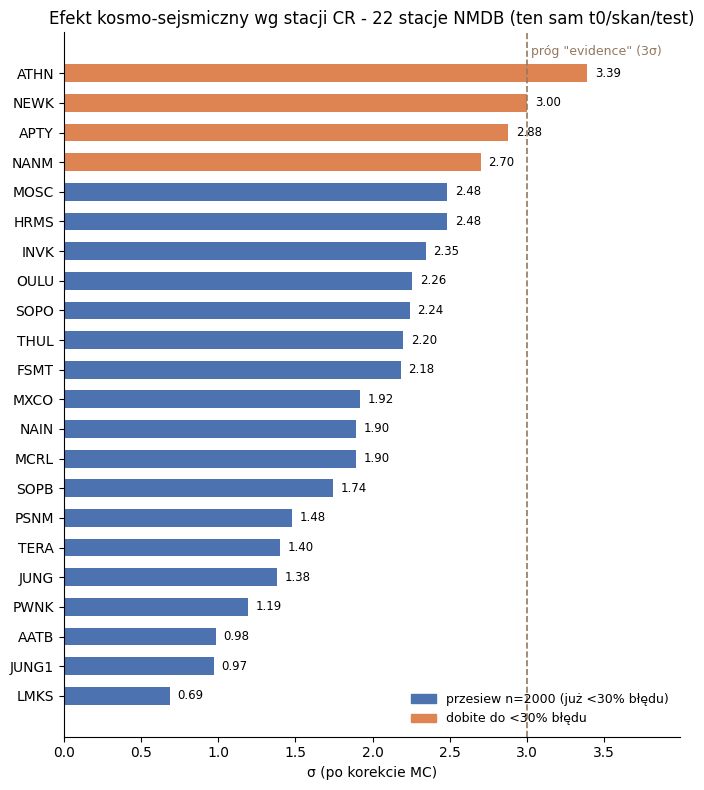

In [26]:
# Wizualizacja: sigma (po korekcie MC) dla wszystkich 22 stacji, sortowane,
# z zaznaczonym progiem "evidence" (3 sigma) i wyroznieniem stacji dobitych
# do wiekszej precyzji (NEWK/APTY/NANM/ATHN).
sigmas_plot = screen_df.set_index("station")["sigma_mc"].copy()
sigmas_plot.update(pd.Series(refined_sigmas))
sigmas_plot = sigmas_plot.sort_values()

colors = ["#DD8452" if s in refined_sigmas else "#4C72B0" for s in sigmas_plot.index]

fig, ax = plt.subplots(figsize=(7, 8))
bars = ax.barh(sigmas_plot.index, sigmas_plot.values, color=colors, height=0.6)
ax.axvline(3.0, color="#937860", linewidth=1.2, linestyle="--")
ax.text(3.0, len(sigmas_plot) - 0.5, " próg \"evidence\" (3σ)", va="bottom", ha="left",
        color="#937860", fontsize=9)

for bar, val in zip(bars, sigmas_plot.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2, f"{val:.2f}",
            va="center", ha="left", fontsize=8.5)

ax.set_xlabel("σ (po korekcie MC)")
ax.set_title("Efekt kosmo-sejsmiczny wg stacji CR - 22 stacje NMDB (ten sam t0/skan/test)")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, sigmas_plot.max() + 0.6)

from matplotlib.patches import Patch
legend_handles = [
    Patch(color="#4C72B0", label="przesiew n=2000 (już <30% błędu)"),
    Patch(color="#DD8452", label="dobite do <30% błędu"),
]
ax.legend(handles=legend_handles, loc="lower right", frameon=False, fontsize=9)

fig.tight_layout()
plt.show()


In [27]:
# Meta-analiza: PRZED naiwnym polaczeniem p-value (Stouffer/Fisher) trzeba
# sprawdzic, czy 22 stacje sa faktycznie niezalezne. Neutron monitory
# mierza w duzej mierze TEN SAM globalny strumien CR - jesli ich odczyty sa
# silnie skorelowane, naiwna kombinacja p-value zawyzy istotnosc (bo
# zaklada k niezaleznych "glosow", a w praktyce jest ich efektywnie mniej).

# Korelacja parami surowych szeregow CR (6h, w oknie analizy) - proxy na
# stopien wspoldzielenia sygnalu miedzy stacjami.
window_mask_fn = lambda s: cr_by_station[s][(cr_by_station[s].index >= t0) & (cr_by_station[s].index <= t0 + pd.Timedelta(days=P_days))]
cr_matrix = pd.DataFrame({s: window_mask_fn(s) for s in GOOD_STATIONS})
corr = cr_matrix.corr()
pairwise = corr.where(~np.eye(len(corr), dtype=bool)).stack()
print(f"Korelacja parami CR miedzy stacjami (w oknie t0): mediana={pairwise.median():.3f}, "
      f"min={pairwise.min():.3f}, max={pairwise.max():.3f}")

# Efektywna liczba niezaleznych testow (przyblizenie Nyholt/Li-Ji:
# k_eff = k / (1 + (k-1)*rho_mean)) - UZYWANE TYLKO do interpretacji "ile
# realnie niezaleznych pomiarow mamy", NIE jako mianownik przy laczeniu
# Z-score (to byla pomylka w poprzedniej wersji tej komorki - k_eff w tym
# miejscu dawal bezsensowny wynik "inf sigma").
k = len(GOOD_STATIONS)
rho_mean = pairwise.mean()
k_eff = k / (1 + (k - 1) * rho_mean)
print(f"k={k} stacji nominalnie, rho_mean={rho_mean:.3f} -> k_eff~={k_eff:.1f} efektywnie niezaleznych")

# Sigma per stacja - NEWK/APTY/NANM/ATHN zastapione precyzyjniejszymi
# pomiarami z dobicia (blad wzgledny <30%), reszta zostaje z przesiewu n=2000
# (juz spelniala prog 30%).
sigmas = screen_df.set_index("station")["sigma_mc"].copy()
sigmas.update(pd.Series(refined_sigmas))
print("\nSigma per stacja (NEWK/APTY/NANM/ATHN zaktualizowane po dobiciu):")
print(sigmas.sort_values(ascending=False).to_string())

# Stouffer's Z dla SKORELOWANYCH testow: poprawny mianownik to
# sqrt(Var(sum Z_i)), a Var(sum Z_i) = k + k*(k-1)*rho_mean (przy zalozeniu
# jednorodnej sredniej korelacji rho_mean miedzy wszystkimi parami,
# wariancja jednostkowa kazdego Z_i). To ROSNIE z rho_mean (nie maleje jak
# bledny k_eff wczesniej) - silniejsza korelacja = mniejszy zysk z
# usredniania wielu "glosow", bo sa niemal identyczne.
Z_sum = sigmas.sum()
Z_naive = Z_sum / np.sqrt(k)
var_corr = k + k * (k - 1) * rho_mean
Z_corrected = Z_sum / np.sqrt(var_corr)
p_naive = norm.sf(Z_naive)
p_corrected = norm.sf(Z_corrected)

print(f"\nStouffer Z (naiwnie, zaklada k={k} niezaleznych): Z={Z_naive:.2f}, p={p_naive:.3e} ({norm.isf(p_naive):.2f} sigma)")
print(f"Stouffer Z (poprawny, uwzgledniajac korelacje rho_mean={rho_mean:.3f}): "
      f"Z={Z_corrected:.2f}, p={p_corrected:.3e} ({norm.isf(p_corrected):.2f} sigma)")


Korelacja parami CR miedzy stacjami (w oknie t0): mediana=0.875, min=0.470, max=0.992
k=22 stacji nominalnie, rho_mean=0.843 -> k_eff~=1.2 efektywnie niezaleznych

Sigma per stacja (NEWK/APTY/NANM/ATHN zaktualizowane po dobiciu):
station
ATHN     3.392
NEWK     3.004
APTY     2.878
NANM       2.7
HRMS     2.484
MOSC     2.484
INVK     2.346
OULU     2.257
SOPO     2.241
THUL     2.197
FSMT     2.183
MXCO     1.919
NAIN     1.896
MCRL     1.896
SOPB     1.745
PSNM     1.476
TERA     1.402
JUNG     1.379
PWNK      1.19
AATB    0.9842
JUNG1   0.9721
LMKS    0.6855

Stouffer Z (naiwnie, zaklada k=22 niezaleznych): Z=9.32, p=5.873e-21 (9.32 sigma)
Stouffer Z (poprawny, uwzgledniajac korelacje rho_mean=0.843): Z=2.15, p=1.559e-02 (2.15 sigma)


In [28]:
# Finalna tabela zbiorcza: wszystkie 22 stacje, z zaznaczeniem ktore byly
# dobijane do progu bledu <30%, a ktore juz spelnialy go przy przesiewie n=2000.
rows = []
for row in ranking.itertuples():
    s = row.station
    if s in refined_details:
        d = refined_details[s]
        rows.append(dict(
            station=s, best_d=row.best_d, best_pcdf=row.best_pcdf,
            n_sims=d["n_sims"], n_hits=d["n_hits"], p_global=d["p_global"],
            sigma=d["sigma"], blad_wzgledny_pct=round(d["rel_err"] * 100),
            dobite=True,
        ))
    else:
        n_hits_screen = int(round(screen_df.set_index("station").loc[s, "p_global"] * n_sims_screen))
        rel_err_screen = 1 / np.sqrt(n_hits_screen) if n_hits_screen > 0 else float("nan")
        rows.append(dict(
            station=s, best_d=row.best_d, best_pcdf=row.best_pcdf,
            n_sims=n_sims_screen, n_hits=n_hits_screen,
            p_global=screen_df.set_index("station").loc[s, "p_global"],
            sigma=screen_df.set_index("station").loc[s, "sigma_mc"],
            blad_wzgledny_pct=round(rel_err_screen * 100),
            dobite=False,
        ))

final_table = pd.DataFrame(rows).sort_values("sigma", ascending=False)
pd.set_option("display.float_format", lambda x: f"{x:.4g}")
print(final_table.to_string(index=False))


station  best_d  best_pcdf  n_sims  n_hits  p_global  sigma  blad_wzgledny_pct  dobite
   ATHN       3   4.15e-07   75000      26 0.0003467  3.392                 20    True
   NEWK       3   6.83e-06    7500      10  0.001333  3.004                 32    True
   APTY       3  2.207e-05    7500      15     0.002  2.878                 26    True
   NANM       3  1.039e-05    3750      13  0.003467    2.7                 28    True
   HRMS       3  9.379e-06    2000      13    0.0065  2.484                 28   False
   MOSC       5  7.587e-05    2000      13    0.0065  2.484                 28   False
   INVK       3  2.633e-05    2000      19    0.0095  2.346                 23   False
   OULU       3  6.455e-05    2000      24     0.012  2.257                 20   False
   SOPO       3  6.455e-05    2000      25    0.0125  2.241                 20   False
   THUL       4  0.0001355    2000      28     0.014  2.197                 19   False
   FSMT       3  4.546e-05    2000      29 